# Clustering with K-Means and DBSCAN — FIRE UdeA Datasets

This notebook applies **K-Means** and **DBSCAN** clustering to two synthetic financial
datasets from the FIRE (Financial Indicators for Research in Education) project at
Universidad de Antioquia.

Student: Jean Carlo Londoño Ocampo

### Workflow for each dataset
1. Load & explore the data
2. Build a preprocessing + KMeans pipeline (K = 2 as baseline)
3. Use the **Elbow Method** to find a good K
4. Re-fit with the best K and visualise clusters
5. Apply **DBSCAN** as an alternative (with k-distance plot to choose eps)
6. **Validate clusters against the true labels** using Adjusted Rand Index (ARI),
   Normalized Mutual Information (NMI), and a confusion matrix

## 0. Imports and global settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# --- Label-validation metrics ---
from sklearn.metrics import (
    adjusted_rand_score,           # ARI: chance-corrected agreement
    normalized_mutual_info_score,  # NMI: information-theoretic agreement
    confusion_matrix,
    silhouette_score,
)
from scipy.optimize import linear_sum_assignment

# Reproducibility
random_state = 42

# Matplotlib styling
plt.rc('font', family='serif', size=12)
print('All imports OK.')

All imports OK.


### Helper functions — cluster-label alignment & evaluation

Cluster IDs are arbitrary (cluster 0 might correspond to true label 1).
We use the **Hungarian algorithm** to find the best one-to-one mapping from
cluster IDs to true labels before computing a confusion matrix.

In [2]:
def align_labels(true_labels, cluster_labels):
    """
    Find the optimal mapping between cluster IDs and true labels
    using the Hungarian algorithm on a contingency matrix.
    Returns (aligned_labels, mapping_dict).
    """
    labels_set = np.unique(true_labels)
    clusters_set = np.unique(cluster_labels[cluster_labels >= 0])  # ignore noise (-1)
    if len(clusters_set) == 0:
        return np.full_like(cluster_labels, -1), {}

    # Build cost matrix (negate because we want to maximise overlap)
    cost = np.zeros((len(clusters_set), len(labels_set)), dtype=int)
    for i, c in enumerate(clusters_set):
        for j, l in enumerate(labels_set):
            cost[i, j] = np.sum((cluster_labels == c) & (true_labels == l))

    row_ind, col_ind = linear_sum_assignment(-cost)
    mapping = {int(clusters_set[r]): int(labels_set[c]) for r, c in zip(row_ind, col_ind)}

    aligned = np.full_like(cluster_labels, fill_value=-1)
    for cid, lid in mapping.items():
        aligned[cluster_labels == cid] = lid
    return aligned, mapping


def evaluate_clustering(true_labels, cluster_labels, dataset_name=''):
    """
    Print ARI, NMI, and a confusion matrix comparing aligned clusters vs true labels.
    Noise points (label == -1) are excluded from the comparison.
    """
    mask = cluster_labels >= 0
    t = true_labels[mask]
    c = cluster_labels[mask]

    if len(t) == 0:
        print(f'=== {dataset_name} ===')
        print('  All points classified as noise — no clusters to evaluate.')
        return 0.0, 0.0

    ari = adjusted_rand_score(t, c)
    nmi = normalized_mutual_info_score(t, c)

    print(f'=== {dataset_name} ===')
    print(f'  Adjusted Rand Index (ARI) : {ari:.4f}')
    print(f'  Normalised Mutual Info    : {nmi:.4f}')

    aligned, mapping = align_labels(t, c)
    print(f'  Cluster -> Label mapping  : {mapping}')

    n_noise = np.sum(~mask)
    if n_noise > 0:
        print(f'  Noise points (excluded)   : {n_noise}')

    if len(mapping) > 0:
        cm = confusion_matrix(t, aligned)
        print(f'\n  Confusion matrix (rows=true, cols=predicted):')
        print(cm)
    print()
    return ari, nmi

---
## 1. Dataset 1 — `dataset_sintetico_FIRE_UdeA.csv`

500 observations, 7 numeric features, binary label column.

In [3]:
# Load the first dataset
df1 = pd.read_csv('dataset_sintetico_FIRE_UdeA.csv')
print(f'Shape: {df1.shape}')
df1.head()

Shape: (500, 8)


,liquidez,dias_efectivo,cfo,participacion_ley30,hhi_fuentes,gastos_personal,tendencia_ingresos,label
0,1.311258,127.178300,3.554020e+06,0.176628,0.467412,9.611198e+07,0.030382,0
1,2.866929,98.816864,-2.670689e+07,0.595641,0.386239,5.503610e+07,0.072156,1
2,2.276384,59.167333,7.603957e+06,0.569217,0.495370,4.894562e+07,-0.023087,0
3,1.916378,147.414128,1.221171e+07,0.525247,0.762599,5.119296e+07,0.145326,0
4,0.721250,124.827955,1.119581e+07,0.121696,0.368166,2.879945e+07,-0.133861,1


In [4]:
# Separate features (X) from the true label (y)
# We keep the label aside for validation — clustering is unsupervised!
y1 = df1['label'].values
X1 = df1.drop(columns=['label']).values

feature_names_1 = df1.drop(columns=['label']).columns.tolist()
print(f'Features ({len(feature_names_1)}): {feature_names_1}')
print(f'Label distribution: {dict(zip(*np.unique(y1, return_counts=True)))}')

Features (7): ['liquidez', 'dias_efectivo', 'cfo', 'participacion_ley30', 'hhi_fuentes', 'gastos_personal', 'tendencia_ingresos']
Label distribution: {np.int64(0): np.int64(223), np.int64(1): np.int64(277)}


### 1.1 Preprocessing pipeline

All features are numeric, so we only need **StandardScaler** so that
K-Means (which is distance-based) treats every feature equally.

In [5]:
# Build the preprocessing step (StandardScaler on all numeric columns)
numeric_transformer_1 = Pipeline(steps=[('scaler', StandardScaler())])

preprocessor_1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_1, np.arange(X1.shape[1])),
    ]
)

### 1.2  K-Means with K = 2 (baseline)

In [6]:
# Build and fit the clustering pipeline with K = 2
clu_kmeans_1 = Pipeline(steps=[
    ('preprocessor', preprocessor_1),
    ('clustering', KMeans(n_clusters=2, random_state=random_state, n_init=10))
])
clu_kmeans_1.fit(X1)

labels_km2_ds1 = clu_kmeans_1['clustering'].labels_
print(f'Inertia with K=2: {clu_kmeans_1["clustering"].inertia_:.2f}')

Inertia with K=2: 3093.17


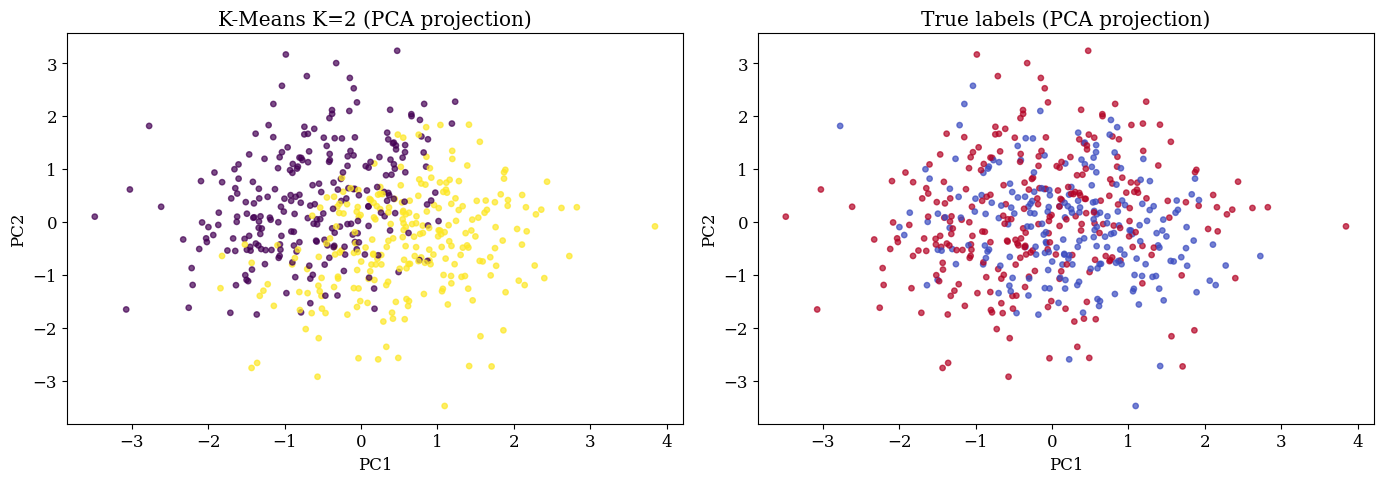

In [7]:
# The data has 7 features, so we project to 2-D with PCA for plotting
X1_scaled = clu_kmeans_1['preprocessor'].transform(X1)
pca_1 = PCA(n_components=2, random_state=random_state)
X1_pca = pca_1.fit_transform(X1_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X1_pca[:, 0], X1_pca[:, 1], c=labels_km2_ds1, cmap='viridis', s=15, alpha=0.7)
axes[0].set_title('K-Means K=2 (PCA projection)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X1_pca[:, 0], X1_pca[:, 1], c=y1, cmap='coolwarm', s=15, alpha=0.7)
axes[1].set_title('True labels (PCA projection)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()

### 1.3  Elbow Method — finding the best K

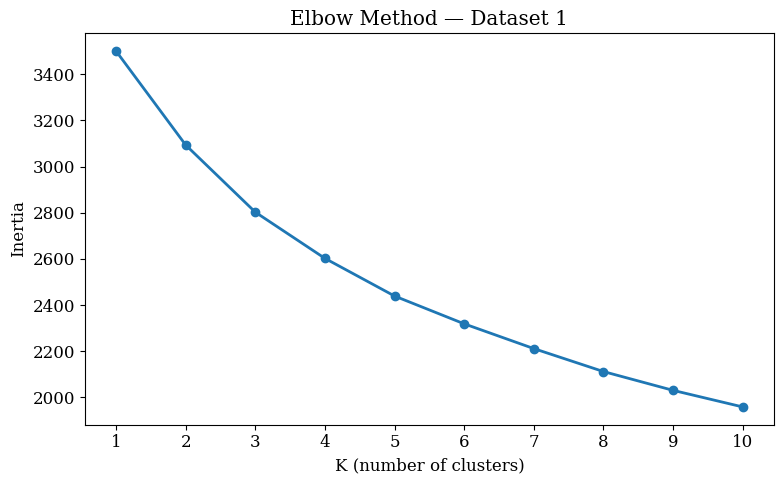

In [8]:
# Compute inertia for K = 1 to 10
inert_1 = []
k_range = list(range(1, 11))

for k in k_range:
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_1),
        ('clustering', KMeans(n_clusters=k, random_state=random_state, n_init=10))
    ])
    pipe.fit(X1)
    inert_1.append(pipe['clustering'].inertia_)

# Plot the elbow curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inert_1, 'o-', linewidth=2)
ax.set_xlabel('K (number of clusters)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Dataset 1')
ax.set_xticks(k_range)
plt.tight_layout()
plt.show()

### 1.4  Re-fit with the best K from the elbow

Choose the K where the inertia curve bends ("elbow").
Since the true label is binary we expect K ~ 2, but the elbow will confirm.

> **Adjust `best_k_1` below** based on the elbow plot you obtained.

In [9]:
# >>> Adjust this value based on the elbow plot above <<<
best_k_1 = 2

clu_best_1 = Pipeline(steps=[
    ('preprocessor', preprocessor_1),
    ('clustering', KMeans(n_clusters=best_k_1, random_state=random_state, n_init=10))
])
clu_best_1.fit(X1)

labels_best_1 = clu_best_1['clustering'].labels_
print(f'Inertia with K={best_k_1}: {clu_best_1["clustering"].inertia_:.2f}')

# Silhouette score: higher = better-defined clusters
sil_1 = silhouette_score(X1_scaled, labels_best_1)
print(f'Silhouette score: {sil_1:.4f}')

Inertia with K=2: 3093.17
Silhouette score: 0.1145


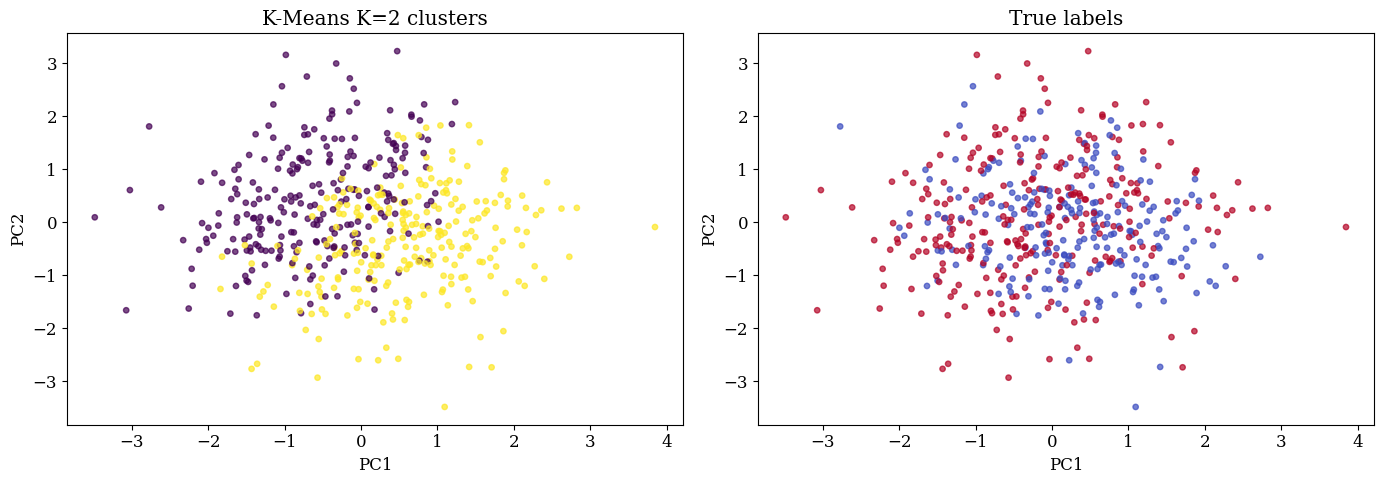

In [10]:
# Final K-Means clusters vs. true labels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X1_pca[:, 0], X1_pca[:, 1], c=labels_best_1, cmap='viridis', s=15, alpha=0.7)
axes[0].set_title(f'K-Means K={best_k_1} clusters')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X1_pca[:, 0], X1_pca[:, 1], c=y1, cmap='coolwarm', s=15, alpha=0.7)
axes[1].set_title('True labels')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()

### 1.5  Label validation — K-Means (Dataset 1)

In [11]:
# Compare K-Means clusters with the true labels
evaluate_clustering(y1, labels_best_1, dataset_name='Dataset 1 — K-Means')

=== Dataset 1 — K-Means ===
  Adjusted Rand Index (ARI) : 0.0596
  Normalised Mutual Info    : 0.0461
  Cluster -> Label mapping  : {0: 1, 1: 0}

  Confusion matrix (rows=true, cols=predicted):
[[144  79]
 [109 168]]



(0.05964018081736121, 0.04609690154098379)

### 1.6  DBSCAN (Dataset 1)

DBSCAN finds clusters based on **density** — no need to specify K.
We must choose **eps** (neighbourhood radius) and **min_samples**.

A useful heuristic is the **k-distance plot**: sort the distance to the k-th nearest
neighbour for every point. The "elbow" in this curve suggests a good eps value.

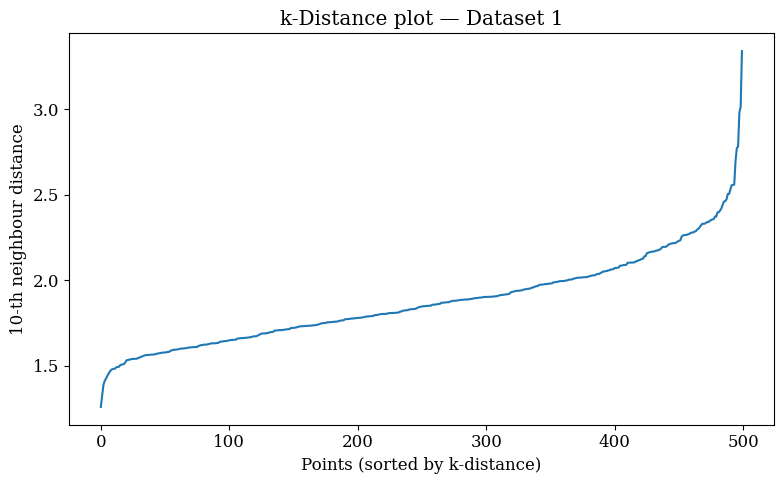

Percentiles of k-distance: {25: np.float64(1.687), 50: np.float64(1.846), 75: np.float64(2.016), 90: np.float64(2.227), 95: np.float64(2.348)}


In [12]:
# k-distance plot to help choose eps (using k = min_samples)
min_samples_1 = 10
nn1 = NearestNeighbors(n_neighbors=min_samples_1).fit(X1_scaled)
distances_1, _ = nn1.kneighbors(X1_scaled)
k_dists_1 = np.sort(distances_1[:, -1])  # distance to the k-th neighbour

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_dists_1, linewidth=1.5)
ax.set_xlabel('Points (sorted by k-distance)')
ax.set_ylabel(f'{min_samples_1}-th neighbour distance')
ax.set_title('k-Distance plot — Dataset 1')
plt.tight_layout()
plt.show()

# Print some percentiles to guide eps selection
print('Percentiles of k-distance:', 
      {p: round(v, 3) for p, v in zip([25, 50, 75, 90, 95], 
      np.percentile(k_dists_1, [25, 50, 75, 90, 95]))})

In [13]:
# Apply DBSCAN — adjust eps based on the k-distance plot above
eps_1 = 1.8   # <<< try values near the elbow of the k-distance plot

clu_dbscan_1 = Pipeline(steps=[
    ('preprocessor', preprocessor_1),
    ('clustering', DBSCAN(eps=eps_1, min_samples=min_samples_1))
])
clu_dbscan_1.fit(X1)

labels_db1 = clu_dbscan_1['clustering'].labels_
unique_labels_1, counts_1 = np.unique(labels_db1, return_counts=True)
print('DBSCAN cluster distribution:')
for lbl, cnt in zip(unique_labels_1, counts_1):
    tag = 'NOISE' if lbl == -1 else f'Cluster {lbl}'
    print(f'  {tag}: {cnt} points')

DBSCAN cluster distribution:
  NOISE: 57 points
  Cluster 0: 443 points


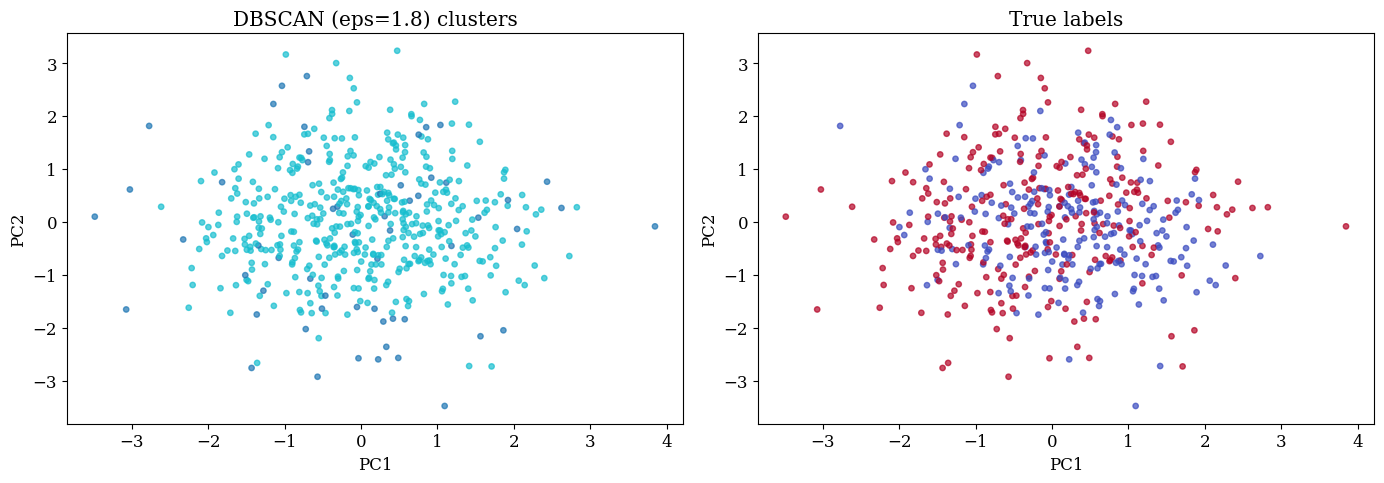

In [14]:
# Visualise DBSCAN results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X1_pca[:, 0], X1_pca[:, 1], c=labels_db1, cmap='tab10', s=15, alpha=0.7)
axes[0].set_title(f'DBSCAN (eps={eps_1}) clusters')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X1_pca[:, 0], X1_pca[:, 1], c=y1, cmap='coolwarm', s=15, alpha=0.7)
axes[1].set_title('True labels')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()

In [15]:
# Label validation — DBSCAN (Dataset 1)
evaluate_clustering(y1, labels_db1, dataset_name='Dataset 1 — DBSCAN')

=== Dataset 1 — DBSCAN ===
  Adjusted Rand Index (ARI) : 0.0000
  Normalised Mutual Info    : 0.0000
  Cluster -> Label mapping  : {0: 1}
  Noise points (excluded)   : 57

  Confusion matrix (rows=true, cols=predicted):
[[  0 210]
 [  0 233]]



(0.0, 0.0)

> **Note:** If DBSCAN groups most points into a single cluster, it means the
> data does not have clearly separated dense regions. This is common with
> financial indicator data where the two classes overlap in feature space.
> DBSCAN is better suited for data with distinct density gaps (e.g. concentric rings).

---
## 2. Dataset 2 — `dataset_sintetico_FIRE_UdeA_realista.csv`

80 observations, multiple features (including categorical `unidad` and integer `anio`),
binary label. This dataset also has **missing values** that we must handle.

In [16]:
df2 = pd.read_csv('dataset_sintetico_FIRE_UdeA_realista.csv')
print(f'Shape: {df2.shape}')
print(f'\nMissing values per column:')
print(df2.isnull().sum()[df2.isnull().sum() > 0])
df2.head()

Shape: (80, 16)

Missing values per column:
liquidez               2
dias_efectivo          1
cfo                    5
participacion_ley30    4
hhi_fuentes            1
endeudamiento          8
tendencia_ingresos     3
dtype: int64


,anio,unidad,ingresos_totales,gastos_personal,liquidez,dias_efectivo,cfo,participacion_ley30,participacion_regalias,participacion_servicios,participacion_matriculas,hhi_fuentes,endeudamiento,tendencia_ingresos,gp_ratio,label
0,2016,Facultad de Ingeniería,1.849089e+11,7.820406e+10,1.805294,93.574425,4.134824e+09,0.364149,0.029874,0.191070,0.246057,0.259059,0.345687,0.032173,0.422933,0
1,2017,Facultad de Ingeniería,1.663532e+11,8.990514e+10,1.718830,74.765485,4.558967e+09,0.323282,0.104119,0.329339,0.220162,0.272821,0.442989,0.030046,0.540447,1
2,2018,Facultad de Ingeniería,1.629845e+11,8.181904e+10,1.323889,98.434310,-1.723374e+10,0.296912,0.054888,0.080071,0.109139,0.320165,NaN,-0.043021,0.502005,1
3,2019,Facultad de Ingeniería,1.527366e+11,8.423677e+10,1.883173,70.617227,1.827772e+10,0.363690,0.066772,0.219408,0.275695,0.266417,0.470299,-0.024940,0.551516,0
4,2020,Facultad de Ingeniería,1.728688e+11,9.884542e+10,1.000427,92.131085,1.329201e+10,0.417744,0.089913,0.273470,0.149092,0.284478,0.421142,0.024130,0.571795,1


In [17]:
# Separate features and true labels
y2 = df2['label'].values

# Drop non-numeric / identifier columns that should not be clustered
drop_cols = ['label', 'unidad', 'anio']
X2_df = df2.drop(columns=drop_cols)
feature_names_2 = X2_df.columns.tolist()

print(f'Numeric features ({len(feature_names_2)}): {feature_names_2}')
print(f'Label distribution: {dict(zip(*np.unique(y2, return_counts=True)))}')

Numeric features (13): ['ingresos_totales', 'gastos_personal', 'liquidez', 'dias_efectivo', 'cfo', 'participacion_ley30', 'participacion_regalias', 'participacion_servicios', 'participacion_matriculas', 'hhi_fuentes', 'endeudamiento', 'tendencia_ingresos', 'gp_ratio']
Label distribution: {np.int64(0): np.int64(42), np.int64(1): np.int64(38)}


### 2.1 Preprocessing pipeline

This dataset has **missing values**, so the pipeline includes a
`SimpleImputer` (median strategy) before scaling.

In [18]:
X2 = X2_df.values

# Pipeline: impute missing values -> standardise
numeric_transformer_2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor_2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_2, np.arange(X2.shape[1])),
    ]
)

### 2.2  K-Means with K = 2 (baseline)

In [19]:
clu_kmeans_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('clustering', KMeans(n_clusters=2, random_state=random_state, n_init=10))
])
clu_kmeans_2.fit(X2)

labels_km2_ds2 = clu_kmeans_2['clustering'].labels_
print(f'Inertia with K=2: {clu_kmeans_2["clustering"].inertia_:.2f}')

Inertia with K=2: 896.70


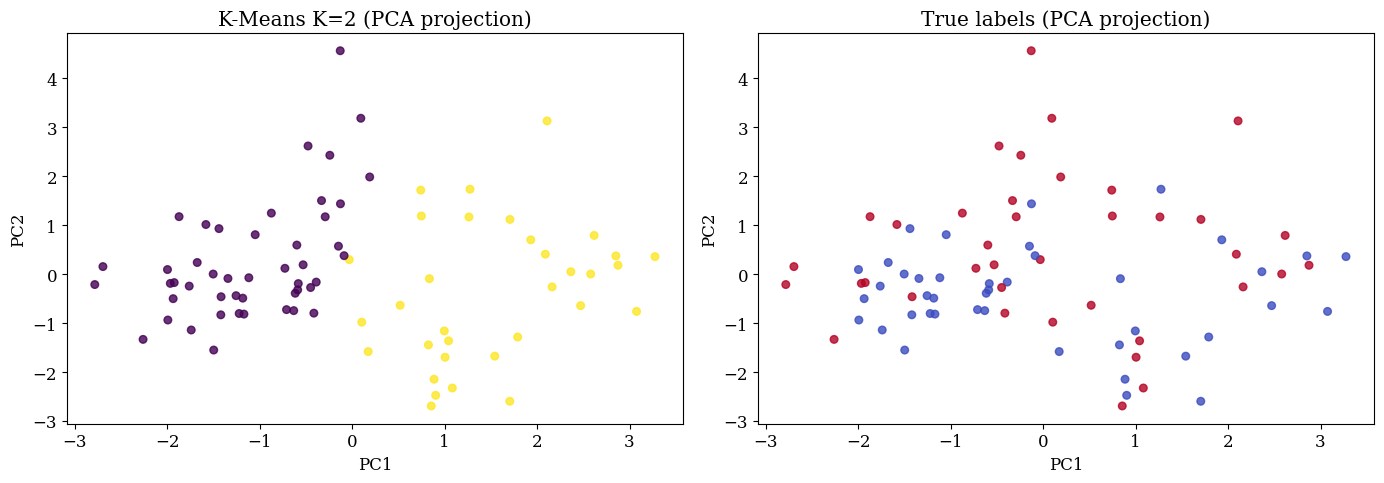

In [20]:
# PCA for 2-D visualisation
X2_scaled = clu_kmeans_2['preprocessor'].transform(X2)
pca_2 = PCA(n_components=2, random_state=random_state)
X2_pca = pca_2.fit_transform(X2_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X2_pca[:, 0], X2_pca[:, 1], c=labels_km2_ds2, cmap='viridis', s=30, alpha=0.8)
axes[0].set_title('K-Means K=2 (PCA projection)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X2_pca[:, 0], X2_pca[:, 1], c=y2, cmap='coolwarm', s=30, alpha=0.8)
axes[1].set_title('True labels (PCA projection)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()

### 2.3  Elbow Method — Dataset 2

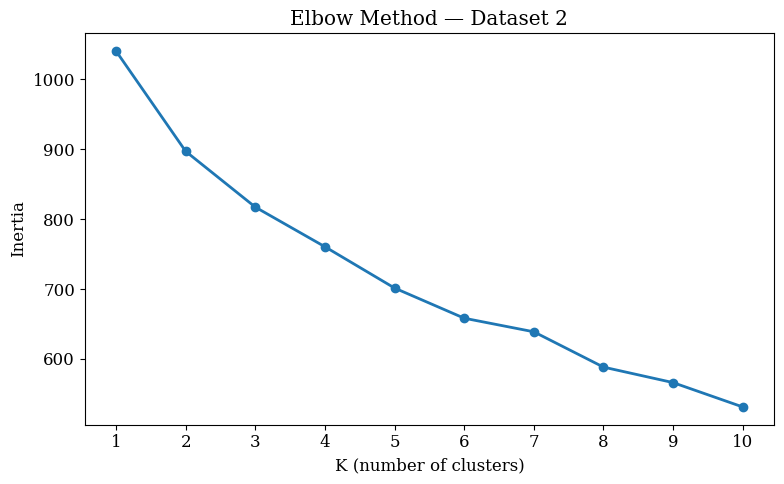

In [21]:
inert_2 = []
k_range = list(range(1, 11))

for k in k_range:
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_2),
        ('clustering', KMeans(n_clusters=k, random_state=random_state, n_init=10))
    ])
    pipe.fit(X2)
    inert_2.append(pipe['clustering'].inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inert_2, 'o-', linewidth=2)
ax.set_xlabel('K (number of clusters)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Dataset 2')
ax.set_xticks(k_range)
plt.tight_layout()
plt.show()

### 2.4  Re-fit with the best K

> **Adjust `best_k_2` below** based on the elbow plot.

In [22]:
# >>> Adjust this value based on the elbow plot above <<<
best_k_2 = 2

clu_best_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('clustering', KMeans(n_clusters=best_k_2, random_state=random_state, n_init=10))
])
clu_best_2.fit(X2)

labels_best_2 = clu_best_2['clustering'].labels_
print(f'Inertia with K={best_k_2}: {clu_best_2["clustering"].inertia_:.2f}')

sil_2 = silhouette_score(X2_scaled, labels_best_2)
print(f'Silhouette score: {sil_2:.4f}')

Inertia with K=2: 896.70
Silhouette score: 0.1409


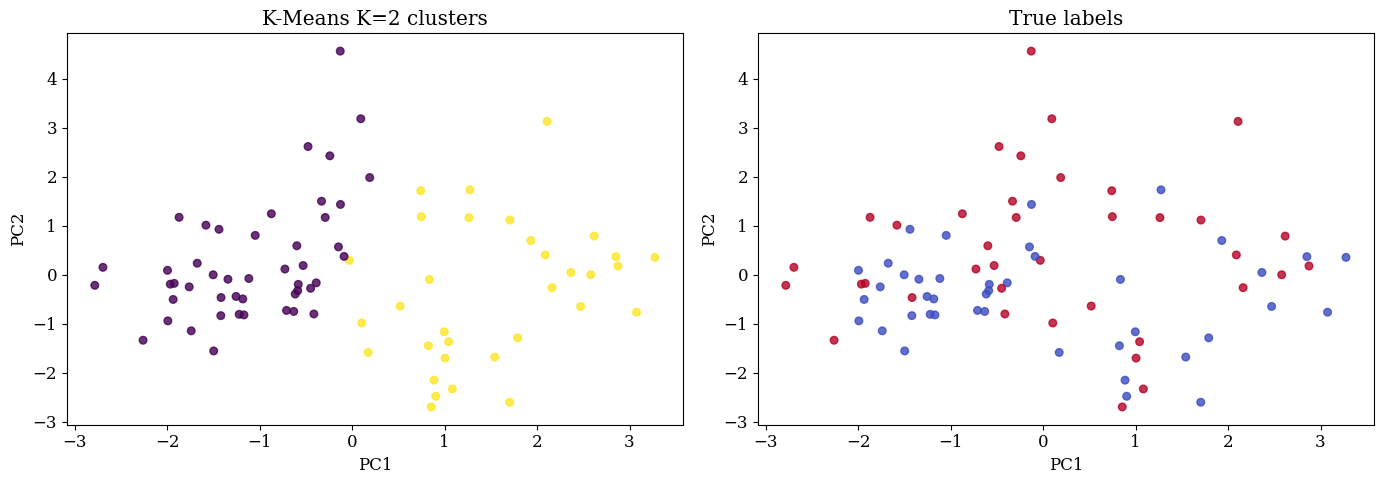

In [23]:
# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X2_pca[:, 0], X2_pca[:, 1], c=labels_best_2, cmap='viridis', s=30, alpha=0.8)
axes[0].set_title(f'K-Means K={best_k_2} clusters')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X2_pca[:, 0], X2_pca[:, 1], c=y2, cmap='coolwarm', s=30, alpha=0.8)
axes[1].set_title('True labels')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()

### 2.5  Label validation — K-Means (Dataset 2)

In [24]:
evaluate_clustering(y2, labels_best_2, dataset_name='Dataset 2 — K-Means')

=== Dataset 2 — K-Means ===
  Adjusted Rand Index (ARI) : -0.0068
  Normalised Mutual Info    : 0.0033
  Cluster -> Label mapping  : {0: 0, 1: 1}

  Confusion matrix (rows=true, cols=predicted):
[[26 16]
 [21 17]]



(-0.006774898432593846, 0.0033142266339549736)

### 2.6  DBSCAN (Dataset 2)

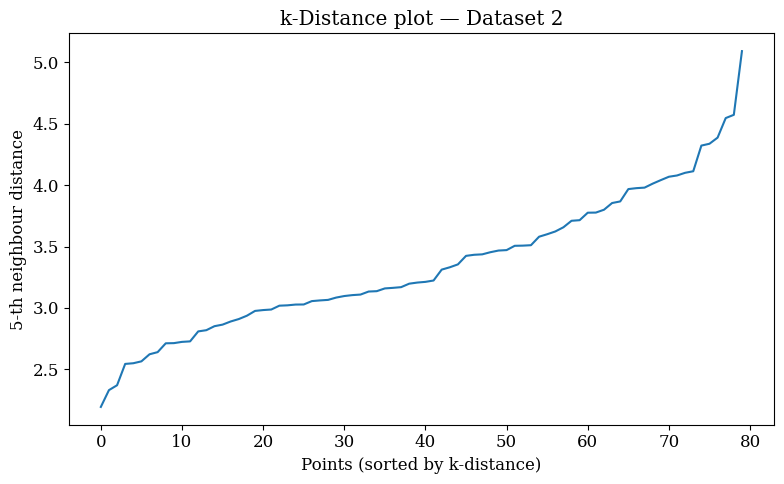

Percentiles of k-distance: {25: np.float64(2.981), 50: np.float64(3.21), 75: np.float64(3.73), 90: np.float64(4.081), 95: np.float64(4.34)}


In [25]:
# k-distance plot for Dataset 2
min_samples_2 = 5   # smaller because we only have 80 points
nn2 = NearestNeighbors(n_neighbors=min_samples_2).fit(X2_scaled)
distances_2, _ = nn2.kneighbors(X2_scaled)
k_dists_2 = np.sort(distances_2[:, -1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_dists_2, linewidth=1.5)
ax.set_xlabel('Points (sorted by k-distance)')
ax.set_ylabel(f'{min_samples_2}-th neighbour distance')
ax.set_title('k-Distance plot — Dataset 2')
plt.tight_layout()
plt.show()

print('Percentiles of k-distance:', 
      {p: round(v, 3) for p, v in zip([25, 50, 75, 90, 95], 
      np.percentile(k_dists_2, [25, 50, 75, 90, 95]))})

In [26]:
# Apply DBSCAN — adjust eps based on the k-distance plot
eps_2 = 3.5   # <<< try values near the elbow of the k-distance curve

clu_dbscan_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('clustering', DBSCAN(eps=eps_2, min_samples=min_samples_2))
])
clu_dbscan_2.fit(X2)

labels_db2 = clu_dbscan_2['clustering'].labels_
unique_labels_2, counts_2 = np.unique(labels_db2, return_counts=True)
print('DBSCAN cluster distribution:')
for lbl, cnt in zip(unique_labels_2, counts_2):
    tag = 'NOISE' if lbl == -1 else f'Cluster {lbl}'
    print(f'  {tag}: {cnt} points')

DBSCAN cluster distribution:
  NOISE: 10 points
  Cluster 0: 70 points


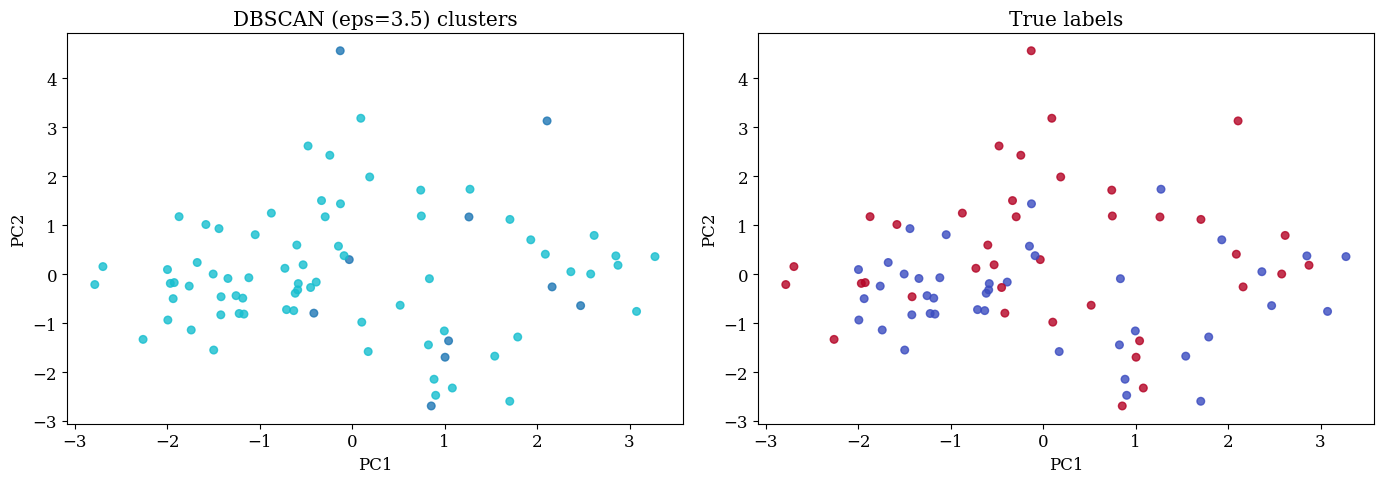

In [27]:
# Visualise DBSCAN results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X2_pca[:, 0], X2_pca[:, 1], c=labels_db2, cmap='tab10', s=30, alpha=0.8)
axes[0].set_title(f'DBSCAN (eps={eps_2}) clusters')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X2_pca[:, 0], X2_pca[:, 1], c=y2, cmap='coolwarm', s=30, alpha=0.8)
axes[1].set_title('True labels')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()

In [28]:
# Label validation — DBSCAN (Dataset 2)
evaluate_clustering(y2, labels_db2, dataset_name='Dataset 2 — DBSCAN')

=== Dataset 2 — DBSCAN ===
  Adjusted Rand Index (ARI) : 0.0000
  Normalised Mutual Info    : 0.0000
  Cluster -> Label mapping  : {0: 0}
  Noise points (excluded)   : 10

  Confusion matrix (rows=true, cols=predicted):
[[41  0]
 [29  0]]



(0.0, 0.0)

---
## 3. Summary comparison

Collect all ARI / NMI scores into a single table.

In [29]:
def safe_ari_nmi(y_true, y_pred):
    """Compute ARI and NMI, excluding noise points."""
    mask = y_pred >= 0
    if mask.sum() == 0:
        return 0.0, 0.0
    return (adjusted_rand_score(y_true[mask], y_pred[mask]),
            normalized_mutual_info_score(y_true[mask], y_pred[mask]))

results = []
for name, yt, yp in [
    ('DS1 — K-Means', y1, labels_best_1),
    ('DS1 — DBSCAN',  y1, labels_db1),
    ('DS2 — K-Means', y2, labels_best_2),
    ('DS2 — DBSCAN',  y2, labels_db2),
]:
    a, n = safe_ari_nmi(yt, yp)
    results.append({'Experiment': name, 'ARI': round(a, 4), 'NMI': round(n, 4)})

summary = pd.DataFrame(results)
summary.style.format({'ARI': '{:.4f}', 'NMI': '{:.4f}'}).set_caption(
    'Cluster quality vs. true labels')

,Experiment,ARI,NMI
0,DS1 — K-Means,0.0596,0.0461
1,DS1 — DBSCAN,0.0000,0.0000
2,DS2 — K-Means,-0.0068,0.0033
3,DS2 — DBSCAN,0.0000,0.0000


---
### Interpretation guide

| Metric | Range | Meaning |
|--------|-------|---------|
| **ARI** | -1 to 1 | 1 = perfect agreement with true labels; 0 = random; < 0 = worse than random |
| **NMI** | 0 to 1 | 1 = perfect information overlap; 0 = independent partitions |
| **Silhouette** | -1 to 1 | 1 = well-separated clusters; 0 = overlapping; < 0 = likely misassigned |

A high ARI / NMI means the unsupervised clusters recover the true label
structure well — the clustering "agrees" with the ground truth.

If DBSCAN returns mostly one big cluster or all noise, it signals that the
data does not have natural density-based separation — K-Means may be more
appropriate (or the classes simply overlap heavily in feature space).